# Notebook 02: Correcting the Bias

This notebook runs the end-to-end **bias correction workflow** to transform IMERG precipitation into bias-corrected products for a **user-selected month and dekad**. The workflow is designed to be reproducible across environments (Colab or local Jupyter) by centralizing all runtime settings in `config.yml` at the project root.

**What this notebook does**
- **Linear Scaling (LS):** adjusts mean bias.
- **Empirical Quantile Mapping (EQM) + Gamma fitting:** aligns distributions.
- **GPD tail adjustment:** improves representation of extremes.
- **Optional Deep Learning (DL) refinement:** learns residual structure from **LSEQM → CPC** to further refine the corrected product.

**Reproducibility note**
- Colab-specific steps (Drive mounting, `pip install`) are explicitly marked.  
- Outside Colab, you can skip those sections and keep the same workflow logic unchanged.
- To port the workflow to a new environment, update only `config.yml` (paths + runtime switches).

---


## 1 Connect Google Drive (Colab only)

This section is only required when running in **Google Colab** and your project/data are stored in Google Drive.

- Mounting Drive makes your repository and datasets accessible under `/content/drive`.
- If you run this notebook locally (Jupyter / VS Code), **skip this section**.

**Expected structure (Drive)**
After mounting, your project root should contain:
- `notebooks/`
- `src/`
- `config.yml` (or `config.yaml`)

Proceed to the code cell below to mount Drive.

In [ ]:
from google.colab import drive
import os

# Check if the drive is mounted
if os.path.exists('/content/drive'):
    # Try to unmount
    try:
        drive.flush_and_unmount()
        print("Successfully unmounted")
    except:
        print("Unmount failed, the drive might not be mounted or busy")

# Mount the drive
drive.mount('/content/drive')

**Troubleshooting:**  
- If Colab becomes disconnected, Reconnect the runtime and rerun the mounting cell.
- If we receive an error such as `Mountpoint must not already contain files`, delete all the sub-folders under "/content/drive" from the Files panel before retrying. We need to delete these one by one starting from the innermost folders, until the last "drive" folder is deleted.


## 2 Install packages (only if needed)

In most cases, **Google Colab already includes the packages required** for this workflow. The most common missing dependency is **`netCDF4`** (NetCDF I/O support).

### Check what is already installed (Colab)
Before installing anything, you can inspect the current environment by running `!pip list`.

- If all required packages are present and only `netCDF4` is missing, install **only `netCDF4`**.
- If other required packages are missing from `!pip list`, install them **together with** `netCDF4` in the code cell below.

### Local Jupyter note
If you are running in a **local environment** (Jupyter / VS Code), assume all dependencies were installed when preparing the environment following the **main repository README**. In that case, you can skip this section.

Proceed to the code cell below only when installation is necessary.

In [ ]:
# In Google Colab, almost all packages already available, except netCDF4
!pip install netCDF4

## 3 Executing the Bias Correction Workflow

In this section, we will execute the full bias correction process. The process involves:

- **Adjusting Values (Linear Scaling, LS):**  
  Correct the mean bias by scaling satellite-based precipitation using the ratio of observed to satellite means.

- **Aligning Distributions (EQM & Gamma Quantile Mapping):**  
  Match the cumulative distribution functions of the satellite data to that of the observed data.  
  Gamma distribution-based quantile mapping provides a rigorous fit to the entire distribution.

- **Preserving Extremes (GPD Tail Adjustment):**  
  Enhance the representation of extreme values by fitting a Generalized Pareto Distribution (GPD) to the tail of the observed data.

- **Refining Corrections with Deep Learning (DL):**
  The DL model is trained to further adjust the EQM-corrected precipitation estimates—especially targeting extreme events and fine-scale spatial variability—to produce the final corrected product.

The code below demonstrates how to set up our environment (by updating configuration paths), loading our datasets, and executing the bias correction workflow.

### Step 1: Setup Environment

This section prepares the notebook runtime so the project modules can be imported consistently.

The setup typically:
- ensures the **project root** is on the Python path (so `import src...` works),
- loads the central configuration file (`config.yml` / `config.yaml`) from the project root, and
- prints key paths to confirm the run is using the intended inputs/outputs.

**Reproducibility principle**
All operational settings (paths, runtime switches, output directories) should come from the configuration file. Avoid editing paths inside notebook cells unless you are deliberately testing an alternative setup.

Proceed to the code cell below to initialize the environment and configuration.

In [ ]:
# Setup: Add project root to Python path
import sys
import os
import importlib
import logging

# Configure logging
logging.basicConfig(level=logging.INFO)

# ---------------------------------------------------------------------------
# Windows DLL fix for conda environments
# ---------------------------------------------------------------------------
if sys.platform == 'win32':
    _conda_prefix = os.environ.get('CONDA_PREFIX') or sys.prefix
    _dll_dirs = [
        os.path.join(_conda_prefix, 'Library', 'bin'),
        os.path.join(_conda_prefix, 'Library', 'lib'),
        os.path.join(_conda_prefix, 'Library', 'mingw-w64', 'bin'),
        os.path.join(_conda_prefix, 'bin'),
        _conda_prefix,
    ]
    for _d in _dll_dirs:
        if os.path.isdir(_d):
            try:
                os.add_dll_directory(_d)
            except OSError:
                pass
            if _d not in os.environ.get('PATH', ''):
                os.environ['PATH'] = _d + os.pathsep + os.environ.get('PATH', '')
    del _conda_prefix, _dll_dirs, _d

# ---------------------------------------------------------------------------
# Project root — hardcoded for local Jupyter.
# Change this path to match your local project location.
# ---------------------------------------------------------------------------

# ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
ROOT = '/content/drive/MyDrive/hybrid-bias-correction'
assert os.path.isfile(os.path.join(ROOT, 'src', 'config.py')), f"Not found: {ROOT}"

if ROOT not in sys.path:
    sys.path.insert(0, ROOT)
for m in [k for k in sys.modules if k.startswith('src')]:
    del sys.modules[m]

# Initialize configuration from config.yml
# (setup_logging() is called automatically when src.config is imported)
import src.config as _cfg
importlib.reload(_cfg)
_cfg.initialize_config()

# Verify configuration
from src import config
print("Configuration loaded successfully:")
print(f"  Main directory  : {config.main_dir}")
print(f"  Input directory : {config.input_dir}")
print(f"  Output directory: {config.output_dir}")
print(f"  IMERGL file     : {config.imergl_file}")
print(f"  CPC file        : {config.cpc_file}")
print(f"  Mask file       : {config.mask_file}")
print(f"  NetCDF engine   : {config.NETCDF_ENGINE}")
print(f"  Interactive     : {config.INTERACTIVE}")

### Step 2: Gather User Inputs

This cell prompts the user to input the month (1–12) and dekad (1, 2, or 3). Input validation is performed to ensure only valid values are accepted. For the third dekad, note that the maximum day of the month will be determined in a later cell.

In [ ]:
# Import Library
import logging

# Configure logging
logging.basicConfig(level=logging.INFO)

# Prompt user for month and dekad
month_input = input("Enter the month (1–12): ").strip()
dekad_input = input("Enter the dekad (1, 2, or 3): ").strip()

try:
    month = int(month_input)
    if not (1 <= month <= 12):
        raise ValueError
except ValueError:
    raise SystemExit("Invalid month. Please provide a number from 1 to 12.")

try:
    dekad = int(dekad_input)
    if dekad not in [1, 2, 3]:
        raise ValueError
except ValueError:
    raise SystemExit("Invalid dekad. Must be 1, 2, or 3.")

logging.info("User selected: month=%s, dekad=%s", month, dekad)

# Format the month as a two-digit string
month_str = f"{month:02d}"

# Set the dekad start and default dekad_str; end day for dekad 3 will be set later
if dekad == 1:
    dekad_str = "01"
    dekad_start, dekad_end = 1, 10
elif dekad == 2:
    dekad_str = "11"
    dekad_start, dekad_end = 11, 20
else:
    dekad_str = "21"
    dekad_start = 21  # dekad_end will be updated after loading dataset


Enter the month (1–12):  1
Enter the dekad (1, 2, or 3):  2


2026-02-22 13:04:40,940 - INFO - User selected: month=1, dekad=2


### Step 3: Load Datasets

In this cell, we import the necessary libraries and load both the IMERG and CPC datasets using the file paths defined in `config.py`.

In [ ]:
# Import Library
import xarray as xr
from src import config
from src.utility import apply_land_sea_mask

# Use auto-detected engine
_engine = config.NETCDF_ENGINE

logging.info("Loading IMERG dataset from: %s (engine=%s)", config.imergl_file, _engine)
imerg_ds = xr.open_dataset(config.imergl_file, decode_times=True, engine=_engine)
logging.info("IMERG dataset loaded. Time range: %s to %s",
             imerg_ds.time.values[0], imerg_ds.time.values[-1])

logging.info("Loading CPC dataset from: %s (engine=%s)", config.cpc_file, _engine)
cpc_ds = xr.open_dataset(config.cpc_file, decode_times=True, engine=_engine)
logging.info("CPC dataset loaded. Time range: %s to %s",
             cpc_ds.time.values[0], cpc_ds.time.values[-1])

# Load native 0.5° CPC for BCSD parameter fitting (Option B).
# This file was produced by Notebook 01 (Step 2b + 3b): gap-filled at native
# 0.5° resolution, NOT regridded to 0.1°.  lseqm() fits CPC distribution
# parameters on this grid and bilinearly interpolates them to the IMERG 0.1°
# grid, eliminating the 5×5 block boundary artefact.
import os
if hasattr(config, 'cpc_native_file') and os.path.isfile(config.cpc_native_file):
    logging.info("Loading native 0.5° CPC from: %s", config.cpc_native_file)
    cpc_ds_native = xr.open_dataset(config.cpc_native_file, decode_times=True, engine=_engine)
    logging.info("Native CPC loaded: %d lat x %d lon (%.2f deg resolution)",
                 len(cpc_ds_native.lat), len(cpc_ds_native.lon),
                 abs(float(cpc_ds_native.lat[1] - cpc_ds_native.lat[0])))
else:
    logging.warning("Native 0.5 deg CPC file not found at %s; "
                    "falling back to cpc_ds (block artefacts may appear)",
                    getattr(config, 'cpc_native_file', 'NOT CONFIGURED'))
    cpc_ds_native = None

# Apply land-sea mask ONCE at data loading to set ocean pixels to NaN.
# This prevents ocean zeros from contaminating statistical calculations downstream.
# The mask is cached internally, so subsequent calls are fast.
logging.info("Applying land-sea mask to both datasets...")
imerg_ds[config.IMERG_PRECIP_VAR] = apply_land_sea_mask(
    imerg_ds[config.IMERG_PRECIP_VAR], config.mask_file
)
cpc_ds[config.CPC_PRECIP_VAR] = apply_land_sea_mask(
    cpc_ds[config.CPC_PRECIP_VAR], config.mask_file
)
logging.info("Land-sea mask applied. Ocean pixels are now NaN.")

After loading, we can preview a summary and a quick plot of the raw IMERG data to ensure it’s loaded correctly.

IMERG Data Summary:
<xarray.Dataset> Size: 3GB
Dimensions:        (time: 8400, lat: 171, lon: 461)
Coordinates:
  * time           (time) datetime64[ns] 67kB 2001-01-01 ... 2023-12-31
  * lon            (lon) float64 4kB 95.05 95.15 95.25 ... 140.9 140.9 141.1
  * lat            (lat) float64 1kB -11.05 -10.95 -10.85 ... 5.75 5.85 5.95
Data variables:
    precipitation  (time, lat, lon) float32 3GB nan nan nan nan ... nan nan nan
Attributes: (12/13)
    CDI:             Climate Data Interface version 2.4.2 (https://mpimet.mpg...
    Conventions:     CF-1.8
    BeginDate:       2001-01-01
    BeginTime:       00:00:00.000Z
    EndDate:         2001-01-01
    EndTime:         23:59:59.999Z
    ...              ...
    InputPointer:    3B-HHR-L.MS.MRG.3IMERG.20010101-S000000-E002959.0000.V07...
    title:           GPM IMERG Late Precipitation L3 1 day 0.1 degree x 0.1 d...
    DOI:             10.5067/GPM/IMERGDL/DAY/07
    ProductionTime:  2024-06-06T17:45:27.018Z
    history:         M

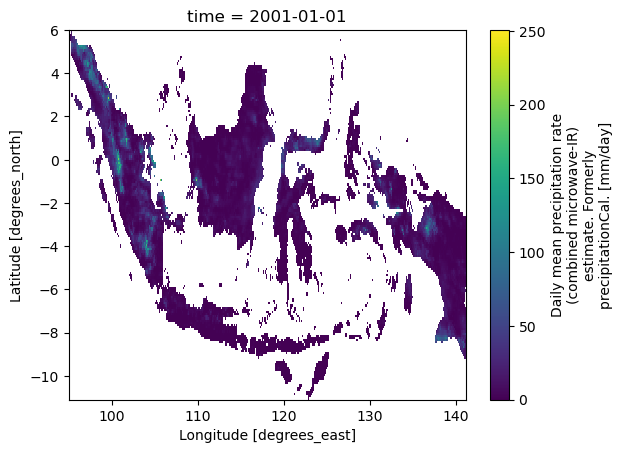

In [ ]:
# Preview a snapshot of the raw IMERG dataset
print("IMERG Data Summary:")
print(imerg_ds)
imerg_ds[config.IMERG_PRECIP_VAR].isel(time=0).plot(cmap='viridis')

CPC Data Summary:
<xarray.Dataset> Size: 3GB
Dimensions:  (time: 8400, lat: 171, lon: 461)
Coordinates:
  * time     (time) datetime64[ns] 67kB 2001-01-01 2001-01-02 ... 2023-12-31
  * lon      (lon) float32 2kB 95.05 95.15 95.25 95.35 ... 140.9 140.9 141.1
  * lat      (lat) float32 684B -11.05 -10.95 -10.85 -10.75 ... 5.75 5.85 5.95
Data variables:
    precip   (time, lat, lon) float32 3GB nan nan nan nan ... nan nan nan nan
Attributes:
    CDI:            Climate Data Interface version 2.4.2 (https://mpimet.mpg....
    Conventions:    CF-1.8
    version:        V1.0
    history:        Wed Jul 17 06:47:38 2024: cdo -z zip_5 mergetime idn_cpc_...
    title:          CPC GLOBAL PRCP V1.0
    dataset_title:  CPC GLOBAL PRCP V1.0
    Source:         ftp://ftp.cpc.ncep.noaa.gov/precip/CPC_UNI_PRCP/
    References:     https://www.psl.noaa.gov/data/gridded/data.cpc.globalprec...
    CDO:            Climate Data Operators version 2.4.2 (https://mpimet.mpg....


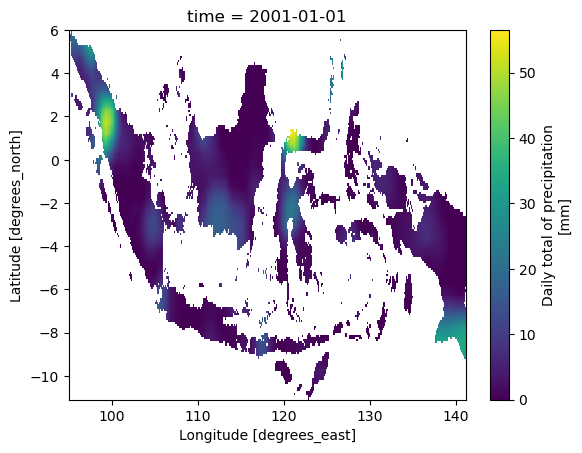

In [ ]:
# Preview a snapshot of the raw CPC dataset
print("CPC Data Summary:")
print(cpc_ds)
cpc_ds[config.CPC_PRECIP_VAR].isel(time=0).plot(cmap='viridis')

### Step 4: Determine Maximum Day for Dekad 3

If the selected dekad is 3, we need to determine the maximum day of the month (to account for leap years). This cell imports and uses the `get_max_day_in_month` function from the `io` module to set `dekad_end` accordingly.

In [ ]:
from src.io import get_max_day_in_month

if dekad == 3:
    dekad_end = get_max_day_in_month(imerg_ds, month)

logging.info("Using month=%s, dekad=%s (day-range: %s – %s)", month, dekad, dekad_start, dekad_end)

2026-02-22 13:05:34,422 - INFO - Using month=1, dekad=2 (day-range: 11 – 20)


### Step 5: Align Datasets

Next, we load the land-sea mask from the mask file defined in `config.py` and align the CPC dataset with the IMERG dataset. This is done using the `reindex_and_align_with_monotonicity` function from `utility.py`.

In [ ]:
from src.utility import load_mask, reindex_and_align_with_monotonicity

# Load the land-sea mask (cached — efficient even if called multiple times)
land_sea_mask = load_mask(config.mask_file)

# Align CPC dataset with IMERG dataset (temporal and spatial alignment)
cpc_ds_aligned, _ = reindex_and_align_with_monotonicity(imerg_ds, cpc_ds, land_sea_mask)
logging.info("Datasets aligned successfully.")

2026-02-22 13:05:44,804 - INFO - Datasets aligned successfully.


### Step 6: Aggregate Multi-Year Dekad Data

We now aggregate the IMERG and CPC datasets across all years for the specified dekad. This uses the `aggregate_data_across_years` function from the `io` module. The aggregated data shapes are then logged.

In [ ]:
from src.io import aggregate_data_across_years

# Aggregate datasets across all years for the specified dekad.
# IMPORTANT: Use cpc_ds_aligned (from Step 5), not the original cpc_ds.
# The original CPC dataset has a different native grid than IMERG.
# After reindex_and_align_with_monotonicity(), cpc_ds_aligned shares
# IMERG's exact lat/lon coordinates, so the inner join inside
# aggregate_data_across_years() will find matching coordinates.
imerg_dekad_data, cpc_dekad_data = aggregate_data_across_years(
    imerg_ds, cpc_ds_aligned, month, dekad_start, dekad_end
)
logging.info("Aggregated IMERG shape: %s", imerg_dekad_data.shape)
logging.info("Aggregated CPC shape: %s", cpc_dekad_data.shape)

2026-02-22 13:05:44,819 - INFO - Aligning IMERG and CPC datasets...
2026-02-22 13:05:47,544 - INFO - After alignment: IMERG has 8400 time steps, CPC has 8400 time steps
2026-02-22 13:05:47,545 - INFO - Creating time-based masks...
2026-02-22 13:05:47,568 - INFO - Applying time masks...
2026-02-22 13:05:51,459 - INFO - Aggregated IMERG shape: (230, 171, 461)
2026-02-22 13:05:51,462 - INFO - Aggregated CPC shape: (230, 171, 461)


We can preview the aggregated data summary and plot an example slice to validate the aggregation results.

Aggregated IMERG Data Summary:
<xarray.DataArray 'precipitation' (time: 230, lat: 171, lon: 461)> Size: 73MB
array([[[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        ...,
        [ 0.3       ,  0.655     ,  1.04      , ...,         nan,
                 nan,         nan],
        [        nan,         nan,  1.105     , ...,         nan,
                 nan,         nan],
        [        nan,         nan,  0.18499999, ...,         nan,
                 nan,         nan]],

       [[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,        

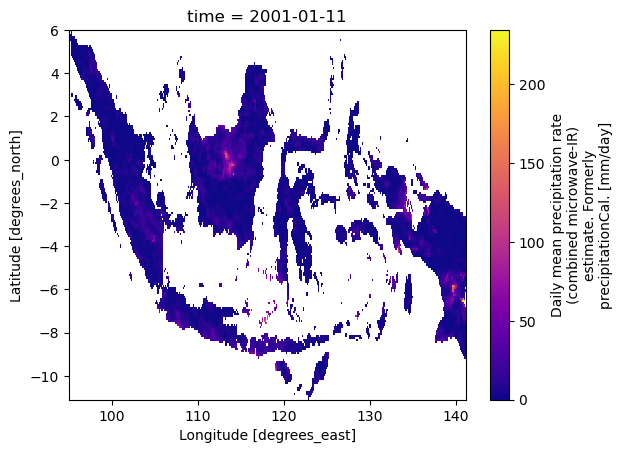

In [ ]:
# Preview the aggregated dekad data for IMERG
print("Aggregated IMERG Data Summary:")
print(imerg_dekad_data)
imerg_dekad_data.isel(time=0).plot(cmap='plasma')


### Step 7: Run LSEQM Bias Correction

In this cell, we run the physical-statistical bias correction pipeline: Linear Scaling (LS) followed by Empirical Quantile Mapping (EQM) with GPD tail adjustment. This is Step 1 of the two-step workflow.

The `lseqm()` function returns both the LSEQM-corrected result and the aggregated CPC dekad data, which will be used as the training target for the DL refinement in Step 8.

Start LSEQM bias correction

In [ ]:
from src.bias_correction import lseqm

logging.info("Running LSEQM bias correction (LS + EQM + GPD)...")

# IMPORTANT: Use cpc_ds_aligned (from Step 5), not the original cpc_ds.
# lseqm() internally calls aggregate_data_across_years(), which uses
# xr.align(join="inner"). This requires that IMERG and CPC share the
# same spatial grid — which is only true after alignment in Step 5.
#
# cpc_native_ds=cpc_ds_native passes the original 0.5° CPC so that
# distribution parameters (gamma, GPD) are fitted at native CPC resolution
# and bilinearly interpolated to the 0.1° IMERG grid. This eliminates
# the 0.5° block boundary artefact (BCSD principle, Wood et al. 2004).
lseqm_result, cpc_dekad_data = lseqm(
    imerg_ds, cpc_ds_aligned, month, dekad_start, dekad_end,
    month_str=month_str,
    dekad_str=dekad_str,
    ls_corrected_precip_path=config.ls_corrected_precip_path,
    lseqm_corrected_precip_path=config.lseqm_corrected_precip_path,
    cpc_native_ds=cpc_ds_native
)
logging.info("LSEQM bias correction completed successfully.")

### Step 8: Train the Deep Learning Model on LSEQM -> CPC

In this cell, we train the DL model using the **LSEQM-corrected data** as input and **CPC** as the target. This is the key difference from the old workflow — the model now learns what LSEQM missed (spatial residuals, extreme refinement) rather than learning the full IMERG->CPC mapping.

This eliminates the domain shift problem: at inference, the model receives LSEQM-corrected data — the same domain it was trained on.

Lets check if tensorflow is importable from THIS kernel

In [ ]:
import sys
print("Python executable:", sys.executable)
print("Python prefix:", sys.prefix)

# Check if tensorflow is importable from THIS kernel
try:
    import tensorflow as tf
    print(f"TensorFlow found: {tf.__version__}")
except ImportError as e:
    print(f"TensorFlow NOT found: {e}")

Python executable: /home/bennyistanto/miniforge3/envs/cuda/bin/python
Python prefix: /home/bennyistanto/miniforge3/envs/cuda


2026-02-22 13:03:21.416509: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-02-22 13:03:21.416723: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-02-22 13:03:21.416767: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-02-22 13:03:22.469775: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow found: 2.14.0


Start training model

In [ ]:
from src.deep_learning import train_bias_correction_model
import os

# Define a model name using the month and dekad string
model_name = f"bias_correction_model_month{month_str}_dekad{dekad_str}"
logging.info("Training or loading model: %s", model_name)

# Train the DL model on LSEQM -> CPC (two-step workflow)
# The model learns what the physical-statistical correction missed
model = train_bias_correction_model(
    lseqm_result, cpc_dekad_data, model_name,
    interactive=config.INTERACTIVE
)

model_path = os.path.join(config.trained_models_path, f"{model_name}.keras")
logging.info("Model path: %s", model_path)

2026-02-22 14:42:07,995 - INFO - Training or loading model: bias_correction_model_month01_dekad11
2026-02-22 14:42:07,998 - INFO - Checking if the model file exists at: /mnt/c/Users/benny/OneDrive/Documents/Github/hybrid-bias-correction/data/output/trained_models/bias_correction_model_month01_dekad11.keras


2026-02-22 14:42:07.468034: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:18:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-02-22 14:42:07.994589: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:18:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-02-22 14:42:07.994825: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:18:00.0/numa_node
Your kernel may have been built without NUMA support.


2026-02-22 14:42:08,403 - INFO - Reducing batch_size from 64 to 9 to fit 78,831 pixels/sample on available GPU memory.


2026-02-22 14:42:08.460164: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:18:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-02-22 14:42:08.460413: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:18:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-02-22 14:42:08.460515: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:18:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-02-22 14:42:08.791058: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:18:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-02-22 14:42:08.793164: I tensorflow/compile

2026-02-22 14:42:09,202 - INFO - Model: "sequential"
2026-02-22 14:42:09,204 - INFO - _________________________________________________________________
2026-02-22 14:42:09,205 - INFO -  Layer (type)                Output Shape              Param #   
2026-02-22 14:42:09,206 - INFO - =================================================================
2026-02-22 14:42:09,208 - INFO -  conv2d (Conv2D)             (None, 171, 461, 32)      320       
2026-02-22 14:42:09,209 - INFO -                                                                  
2026-02-22 14:42:09,210 - INFO -  max_pooling2d (MaxPooling2  (None, 85, 230, 32)       0         
2026-02-22 14:42:09,211 - INFO -  D)                                                              
2026-02-22 14:42:09,212 - INFO -                                                                  
2026-02-22 14:42:09,214 - INFO -  dropout (Dropout)           (None, 85, 230, 32)       0         
2026-02-22 14:42:09,215 - INFO -                        

2026-02-22 14:42:10.583837: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape insequential/dropout/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
2026-02-22 14:42:11.081460: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:442] Loaded cuDNN version 8907
2026-02-22 14:42:11.811714: I tensorflow/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-02-22 14:42:11.977712: I tensorflow/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-02-22 14:42:11.977936: W tensorflow/compiler/xla/stream_executor/gpu/asm_compiler.cc:109] Couldn't get ptxas version : FAILED_PRECONDITION: Couldn't get ptxas/nvlink version string: INTERNAL: Couldn't invoke ptxas --version
2026-02-22 14:42:12.144567: I tensorflow/tsl/platform/default/subprocess.cc:304] Start cannot spawn child

InternalError: Graph execution error:

Detected at node Adam/StatefulPartitionedCall_6 defined at (most recent call last):
  File "/home/bennyistanto/miniforge3/envs/cuda/lib/python3.11/runpy.py", line 198, in _run_module_as_main

  File "/home/bennyistanto/miniforge3/envs/cuda/lib/python3.11/runpy.py", line 88, in _run_code

  File "/home/bennyistanto/miniforge3/envs/cuda/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>

  File "/home/bennyistanto/miniforge3/envs/cuda/lib/python3.11/site-packages/traitlets/config/application.py", line 1075, in launch_instance

  File "/home/bennyistanto/miniforge3/envs/cuda/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 739, in start

  File "/home/bennyistanto/miniforge3/envs/cuda/lib/python3.11/site-packages/tornado/platform/asyncio.py", line 211, in start

  File "/home/bennyistanto/miniforge3/envs/cuda/lib/python3.11/asyncio/base_events.py", line 604, in run_forever

  File "/home/bennyistanto/miniforge3/envs/c

### Step 9: Load or Create Station Density Confidence Mask (Optional)

If `use_confidence_mask: true` is set in `config.yml` and a station file is available, this cell computes a spatial confidence mask based on gauge station density. The mask modulates the DL blending alpha: areas with many CPC stations get more DL influence, while station-sparse areas revert to pure LSEQM.

If the feature is disabled (default) or no station file is configured, this step is skipped and uniform `blend_alpha` is used everywhere (backward compatible with the original workflow).

**To enable:** Set `use_confidence_mask: true` in the `station_density:` section of `config.yml`.

In [ ]:
from src import config

confidence_mask = None  # Default: no spatial modulation (uniform blend_alpha)

if (config.USE_CONFIDENCE_MASK
    and config.STATION_FILE
    and os.path.isfile(config.STATION_FILE)):
    from src.station_density import get_or_create_confidence_mask

    logging.info("Station density confidence mask: ENABLED")
    logging.info("Station file: %s", config.STATION_FILE)

    # Use LSEQM grid coordinates as the target working grid
    confidence_mask = get_or_create_confidence_mask(
        station_file=config.STATION_FILE,
        confidence_mask_file=config.CONFIDENCE_MASK_FILE,
        target_lat=lseqm_result.lat.values,
        target_lon=lseqm_result.lon.values,
        cpc_resolution=config.DENSITY_CPC_RESOLUTION,
        smoothing_sigma=config.DENSITY_SMOOTHING_SIGMA,
        saturation_count=config.DENSITY_SATURATION_COUNT,
        lat_range=config.DENSITY_LAT_RANGE,
        lon_range=config.DENSITY_LON_RANGE,
    )
    logging.info("Confidence mask shape: %s", confidence_mask.shape)
    logging.info("Confidence range: [%.3f, %.3f]",
                 float(confidence_mask.min()), float(confidence_mask.max()))

    # Quick visualization
    confidence_mask.plot(cmap='RdYlGn', vmin=0, vmax=1)
else:
    # Explain why the confidence mask is disabled
    if not config.USE_CONFIDENCE_MASK:
        logging.info("Station density confidence mask: DISABLED (use_confidence_mask: false in config.yml)")
        logging.info("  To enable: set 'use_confidence_mask: true' in the station_density section")
    elif not config.STATION_FILE:
        logging.info("Station density confidence mask: DISABLED (no station_file configured)")
    else:
        logging.info("Station density confidence mask: DISABLED (station file not found: %s)",
                     config.STATION_FILE)
    logging.info("Using uniform blend_alpha=%.2f everywhere", config.DL_BLEND_ALPHA)

### Step 10: Apply DL Refinement and Save

Finally, we apply the trained DL model to refine extreme pixels in the LSEQM result. The DL prediction is alpha-blended with the LSEQM values (default: 70% LSEQM, 30% DL) to ensure the physical-statistical backbone dominates while DL provides spatial refinement for extremes.

In [ ]:
from src.deep_learning import apply_deeplearning_model
from src.io import save_corrected_precip

logging.info("Applying DL refinement to LSEQM result...")

# Apply the trained DL model to refine extreme pixels
# If confidence_mask is available, alpha is spatially modulated by station density
corrected_precip = apply_deeplearning_model(model, lseqm_result,
                                            confidence_mask=confidence_mask)

# Ensure non-negative precipitation values
corrected_precip = corrected_precip.clip(min=0)

# Save DL-corrected precipitation
logging.info("Saving LSEQMDL corrected precipitation...")
save_corrected_precip(
    corrected_precip,
    lseqm_result,
    method_abbr="lseqmdl",
    method_full="Hybrid Deep Learning-Physical (Linear Scaling and Empirical Quantile Mapping) Approach",
    folder=config.lseqmdl_corrected_precip_path,
    dekad_str=dekad_str,
    month_str=month_str
)
logging.info("LSEQMDL bias correction completed successfully.")
print("Bias correction process finished. Please check the output directories for corrected datasets.")

After processing, we can preview a plot of the corrected precipitation data to visually verify the results.

In [ ]:
# Preview final bias-corrected data
print("Corrected Precipitation Data Summary:")
print(corrected_precip)
corrected_precip.isel(time=0).plot(cmap='inferno')


---


## Summary

This notebook produced bias-corrected precipitation outputs for the selected month and dekad using three correction stages:

- **LS (mean bias correction)** saved to: `config.ls_corrected_precip_path`
- **LSEQM (LS + EQM + GPD tail adjustment)** saved to: `config.lseqm_corrected_precip_path`
- **LSEQM+DL (hybrid refinement)** saved to: `config.lseqmdl_corrected_precip_path`

If Deep Learning is enabled, the trained model is saved under:
- `config.trained_models_path` (as a `.keras` file, named by month/dekad)

The corrected NetCDF outputs generated here are the inputs for **Notebook 03 (Measuring Performances)**, which computes verification metrics to quantify improvements across methods.


---

## Batch Run - All Months and Dekads

Run this cell to execute the **full LSEQMDL bias correction pipeline**
(LS → LSEQM → DL train → DL apply → save) for every month×dekad combination
(12 months × 3 dekads = 36 periods).

Existing DL models are reloaded silently without prompting. Periods that
fail are skipped with a warning so the batch can continue.

**Prerequisites - run these cells first (skip Steps 2 and 4–10):**

| Cell | Purpose |
|------|---------|
| Step 1 | Environment setup, imports, `config` |
| Step 3 | Load IMERG + CPC datasets (`imerg_ds`, `cpc_ds`) |
| Step 5 | Align CPC to IMERG grid (`cpc_ds_aligned`) |

In [ ]:
"""
Batch run - full LSEQMDL pipeline for all 36 month×dekad periods.

Requires: imerg_ds, cpc_ds_aligned, cpc_ds_native (from Steps 3 + 5).
"""
from src.bias_correction import run_correction_pipeline

n_done = 0
n_skip = 0

for _m in range(1, 5):
    for _d in [1, 2, 3]:
        tag = f"month {_m:02d} dekad {_d}"
        print(f"\n{'='*60}")
        print(f"▸ {tag}")
        print(f"{'='*60}")
        try:
            out_path = run_correction_pipeline(
                imerg_ds, cpc_ds_aligned, _m, _d,
                cpc_native_ds=cpc_ds_native
            )
            n_done += 1
            print(f"✓ {tag} — saved: {out_path}")
        except Exception as e:
            n_skip += 1
            print(f"✗ {tag} — FAILED: {e}")

print(f"\n{'='*60}")
print(f"Batch complete: {n_done} periods done, {n_skip} skipped.")
print(f"{'='*60}")

---

## End of Code